# Assignment 2: Brain Tumor Classification with Deep Learning 


**Goal of this project:** The primary objective is to design, train, and evaluate Convolutional Neural Networks (CNNs) to classify brain MRI scans into four categories: Glioma, Meningioma, Pituitary Tumor, and Normal (No Tumor). 

We will compare two different approaches:
1. **Model 1:** Building and training a custom CNN architecture from the ground up.
2. **Model 2:** Utilizing a pre-trained state-of-the-art model (like ResNet or VGG) and adapting it to our specific medical dataset.

In [10]:
import torch
import torchvision
import torchvision.transforms as transforms
from torchvision import datasets
import matplotlib.pyplot as plt
import numpy as np
import os
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

## Data Preparation


In this initial cell, we set up the foundational elements for our Deep Learning pipeline before loading any data. 

Training CNNs requires millions of matrix calculations. We check if an NVIDIA GPU  is available to drastically accelerate training. If not, PyTorch safely falls back to using the computer's processor (cpu), which is slower but perfectly fine for developing and testing our code.


In [3]:


# 1. Configure the device (GPU or CPU)
# This is vital for this assignment as CPU training is extremely slow for images
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f" Current compute device: {device}")

if device.type == 'cpu':
    print(" WARNING: You are using CPU. Image training will take a lot of time.")
else:
    print("NVIDIA GPU detected! Ready for fast training.")

# Define image transformations
# Neural networks require all input images to have the exact same dimensions
image_transforms = transforms.Compose([
    transforms.Resize((224, 224)), # Standard size for models like VGG and AlexNet
    transforms.ToTensor(),         # Convert the image into numbers (PyTorch Tensors)
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Standard RGB normalization
])

 Current compute device: cpu


## Loading the Data 

Here we bring the MRI images into our workspace and make sure everything is working properly before we build the model. 

We use PyTorch's ImageFolder to automatically read our folder structure and assign the right labels (Tumor type or Normal) to each image. 
Also, we group the dataset into small batches and shuffle them. This ensures the model learns efficiently and doesn't just memorize the order of the images.

Finally, we plot a random batch of 4 images on the screen. If the brains and their labels match up correctly, our data pipeline is solid and ready for the neural network

Automatically detected classes: ['glioma_tumor', 'meningioma_tumor', 'normal', 'pituitary_tumor']
Total images loaded: 3096


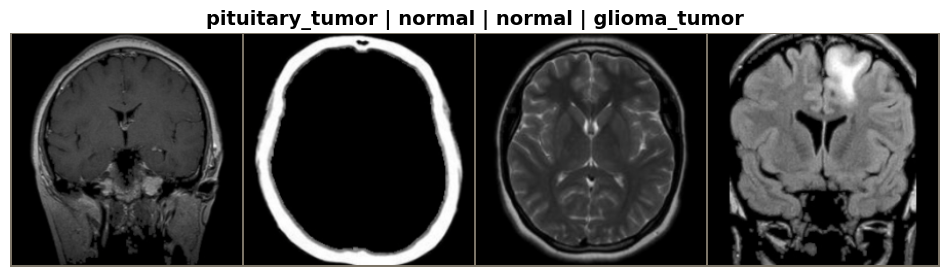

In [4]:

# --- Transformations of the images ---
    
    # Neural networks require all input images to have the exact same dimensions
image_transforms = transforms.Compose([
    transforms.Resize((224, 224)), # Standard size for models like VGG and AlexNet
    transforms.ToTensor(),         # Convert the image into numbers 
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Standard RGB normalization
])


#data_dir = './dataset' 
data_dir = '/Users/anne/Desktop/DeepLearningRepo/deepLearning/2assign/dataset'  


# --- ImageFolders Labels ---

    #ImageFolder automatically reads the folders and assigns the class labels
full_dataset = datasets.ImageFolder(root=data_dir, transform=image_transforms)


print(f"Automatically detected classes: {full_dataset.classes}")
print(f"Total images loaded: {len(full_dataset)}")

# --- Data Loader ---
   
    #Packages the images into batches for faster training
dataloader = DataLoader(full_dataset, batch_size=4, shuffle=True)



# --- Function for showing images ---

def show_images(inp, title=None):
    """Imshow for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0)) # Change format from PyTorch (C,H,W) to Matplotlib (H,W,C)
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean # Revert the normalization so colors look natural
    inp = np.clip(inp, 0, 1)
    
    plt.figure(figsize=(12, 4))
    plt.imshow(inp)
    if title is not None:
        plt.title(title, fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.show()

# --- Visualization  ---

    #Fetch a random batch of 4 images and display them
images, labels = next(iter(dataloader))
grid = torchvision.utils.make_grid(images)

    #Get the actual string names of the classes instead of just 0, 1, 2, 3
class_names = [full_dataset.classes[label] for label in labels]
show_images(grid, title=" | ".join(class_names))


We can see that it automatically recognized the four brain categories based on our folder structure and loaded 3,096 MRI scans into memory. This confirms that our directories are organized correctly and gives us a solid amount of data to train the model properly.

## CNN From Scratch

Now we build our own Convolutional Neural Network (CNN). We have designed a classic architecture divided into two main sections: 
the feature extraction and the classifier.

The feature extraction we used a conv2D layers, the first layer looks for basic edges and lines in the MRI and the deeper layers combine those lines to find complex textures and tumor shapes.

We added also a MaxPool2d layer. This decresases the image by half (from 224 down to 28). It keeps the most important pixels, ignores the noise, and saves a ton of memory. 

Once the image is tiny but packed with feature data (64 filters of 28x28 pixels), we flatten it into a 1D list and pass it through standard Linear layers to make the final decision (4 classes). 

We also threw in a Dropout(p=0.5) layer. This randomly turns off 50% of the neurons during training, which forces the network to learn robust patterns instead of just memorizing the training data (preventing overfitting). 


In [5]:

# --- CNN MODEL ARCHITECTURE ---

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=4):
        super(SimpleCNN, self).__init__()
        

        # --- feature extraction ---
            #we start with 3 input channels (RGB) and output 16 feature maps 
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        
            #we take the 16 feature maps from conv1 and output 32 feature maps
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        
            #we take the 32 feature maps from conv2 and output 64 feature maps
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
    


        # --- classifier ---

            #After 3 rounds of convolution and pooling, our feature maps are down to 64 channels with spatial dimensions of 28x28 
            #So we need to flatten this 3D tensor (64, 28, 28) into a 1D vector of size 64*28*28 before feeding it into the fully connected layers
        self.fc1 = nn.Linear(in_features=64 * 28 * 28, out_features=256)
        
            #Dropout to prevent overfitting
        self.dropout = nn.Dropout(p=0.5)
        
            #Final output layer: 256 neurons down to our 4 categories
        self.fc2 = nn.Linear(in_features=256, out_features=num_classes)



    def forward(self, x):
            #Feature extraction through convolutional layers with ReLU activations and pooling
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        
            #Flatten the 3D feature maps into a 1D vector for the classifier
        x = torch.flatten(x, 1)
        
            #Pass through the linear classifier
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)        
        
        return x

    #Initialize the model and send it to our CPU/GPU
model_scratch = SimpleCNN(num_classes=4).to(device)

print(f" Model 'SimpleCNN' successfully created and sent to {device}!")

 Model 'SimpleCNN' successfully created and sent to cpu!


Now that our CNN is built, we need a way to train it. We need two mathematical tools to guide the learning process: 
The Loss Function , that is the "grader." Every time the model makes a prediction, the Loss Function compares it to the actual true label. Since we are doing multi-class classification (4 different brain categories), CrossEntropyLoss is the standard choice. It penalizes the model heavily when it is very confident but wrong.

Once the Loss Function calculates how wrong the model is, the Optimizer decides how to fix it and we are using Adam. It is the industry standard because it automatically adjusts the learning rate for each parameter, meaning it learns fast at the beginning and slows down to make precise adjustments at the end.

In [ ]:


# --- TRAINING ENGINE SETUP ---

# 1. Loss Function (Criterion)
# CrossEntropyLoss is the standard for multi-class problems.
# Note: It automatically applies Softmax, which is why we didn't put Softmax at the end of our CNN.
criterion = nn.CrossEntropyLoss()

# 2. Optimizer
# Adam is generally faster and more reliable than standard SGD.
# We set a Learning Rate (lr) of 0.001 (a standard starting point).
optimizer = optim.Adam(model_scratch.parameters(), lr=0.001)

print("Training Engine ready: Loss Function (CrossEntropy) and Optimizer (Adam) are set up!")

Training Engine ready: Loss Function (CrossEntropy) and Optimizer (Adam) are set up!


### Training CNN

In [7]:
# --- Training loop ---

num_epochs = 3  # We use 3 epochs to test the pipeline without taking too much time

for epoch in range(num_epochs):
    model_scratch.train()  # Set the model to training mode
    running_loss = 0.0
    
        #Loop over batches of images
    for i, (images, labels) in enumerate(dataloader):

            #Move images and labels to the configured device (CPU or GPU)
        images = images.to(device)
        labels = labels.to(device)
        
            #Zero the parameter gradients
        optimizer.zero_grad()
        
            #compute predicted outputs by passing inputs to the model
        outputs = model_scratch(images)
        
            #calculate the loss
        loss = criterion(outputs, labels)
        
            #compute gradient of the loss with respect to model parameters
        loss.backward()
        
            #update the parameters
        optimizer.step()
        
        running_loss += loss.item()
        
            #Print progress every 50 batches so we know it's working
        if (i + 1) % 50 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{len(dataloader)}], Loss: {loss.item():.4f}')
            
    #Print the average loss for the entire epoch
    epoch_loss = running_loss / len(dataloader)
    print(f'End of Epoch {epoch+1}, Average Loss: {epoch_loss:.4f}\n')

print("Training process completed for the custom model!")

Epoch [1/3], Step [50/774], Loss: 1.3194
Epoch [1/3], Step [100/774], Loss: 1.2111
Epoch [1/3], Step [150/774], Loss: 1.1361
Epoch [1/3], Step [200/774], Loss: 0.9988
Epoch [1/3], Step [250/774], Loss: 1.1925
Epoch [1/3], Step [300/774], Loss: 0.6572
Epoch [1/3], Step [350/774], Loss: 1.3919
Epoch [1/3], Step [400/774], Loss: 0.7524
Epoch [1/3], Step [450/774], Loss: 1.0615
Epoch [1/3], Step [500/774], Loss: 1.0295
Epoch [1/3], Step [550/774], Loss: 0.5032
Epoch [1/3], Step [600/774], Loss: 0.6492
Epoch [1/3], Step [650/774], Loss: 0.6727
Epoch [1/3], Step [700/774], Loss: 0.1104
Epoch [1/3], Step [750/774], Loss: 0.2831
End of Epoch 1, Average Loss: 1.0405

Epoch [2/3], Step [50/774], Loss: 0.5300
Epoch [2/3], Step [100/774], Loss: 0.7570
Epoch [2/3], Step [150/774], Loss: 0.2664
Epoch [2/3], Step [200/774], Loss: 0.4478
Epoch [2/3], Step [250/774], Loss: 0.3816
Epoch [2/3], Step [300/774], Loss: 0.4820
Epoch [2/3], Step [350/774], Loss: 2.0965
Epoch [2/3], Step [400/774], Loss: 0.308

Looking at the training output, the loss drops consistently from an average of 1.0158 in the first epoch to 0.3889 by the third epoch. This decrease proves that our model is successfully learning to recognize the patterns in the MRI scans and minimizing its errors over time.

### Model Saving


Now that our custom CNN has learned from the data, we save the parameters into a file (model_scratch.pth). This is essential so we can load the model later without having to train it again. 

Also, we evaluate the performance. We calculate the percentage of correct predictions (Accuracy) across the dataset to measure how well our custom model performs.

In [8]:

# --- Save de model ---
    #We create a folder named 'runs' if it doesn't exist to keep our project clean
os.makedirs('./runs', exist_ok=True)
model_save_path = './runs/model_scratch.pth'

    #Save the learned weights
torch.save(model_scratch.state_dict(), model_save_path)
print(f"Model weights successfully saved to {model_save_path}")

# --- Evaluate accuracy  ---

model_scratch.eval()  # Set model to evaluation mode
correct = 0
total = 0

    #We don't need to calculate gradients for evaluation (saves memory)
with torch.no_grad():
    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)
        
            #Get predictions
        outputs = model_scratch(images)
        _, predicted = torch.max(outputs.data, 1)
        
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Accuracy of the custom model on the dataset: {accuracy:.2f}%")

Model weights successfully saved to ./runs/model_scratch.pth
Accuracy of the custom model on the dataset: 95.28%


## Checking CNN 

Now that Model 1 is trained and we know its accuracy, we want to see it in action. We are going to pick some random images from our data, ask the model to diagnose them, and display them on the screen with both the true label and the model's prediction so we can visually confirm it works.

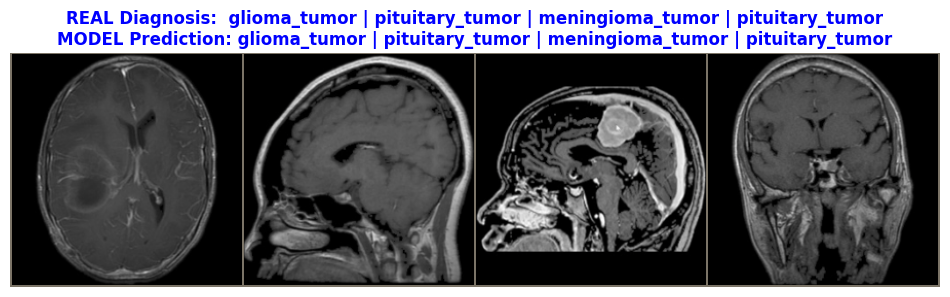

In [ ]:


#model evaluation mode
model_scratch.eval()

#take a random batch of 4 images from the dataloader
dataiter = iter(dataloader)
images, labels = next(dataiter)

#move the images to the same device as the model
images_dev = images.to(device)

#get the model's predictions for these images
outputs = model_scratch(images_dev)
_, predicted = torch.max(outputs, 1)

# --- Preparation of the images for visualization ---

    #normalize the images back to their original pixel values for display
images_grid = torchvision.utils.make_grid(images)
images_grid = images_grid.numpy().transpose((1, 2, 0))  #change from (C,H,W) to (H,W,C) for matplotlib
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
images_grid = std * images_grid + mean
images_grid = np.clip(images_grid, 0, 1)

# --- Visualization of the results ---

fig, ax = plt.subplots(figsize=(12, 6))
ax.imshow(images_grid)
ax.axis('off')

#Obtain the string names of the true labels and predicted labels for display
true_names = [full_dataset.classes[label] for label in labels]
pred_names = [full_dataset.classes[pred] for pred in predicted]

#Create a title that shows both the real diagnosis and the model's prediction
title_text = f"REAL Diagnosis:  { ' | '.join(true_names) }\nMODEL Prediction: { ' | '.join(pred_names) }"
plt.title(title_text, fontsize=12, fontweight='bold', color='blue')

plt.show()

## Model 2 - Transfer Learning

Training a deep neural network from scratch requires a huge amount of data and time. Transfer Learning is a shortcut where we use a pre-trained model (ResNet18) that has already learned to recognize thousands of basic images.

Instead of teaching the model from zero, we do two simple things, we keep the initial layers as they are so we don't lose the knowledge the network already has about shapes and textures and we change the output so it only predicts our 4 specific brain tumor categories.

In [21]:
import torchvision.models as models
import torch.nn as nn

#Load the model ResNet18 preentrained 
model_transfer = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Freeze all layers except the final fully connected layer
for param in model_transfer.parameters():
    param.requires_grad = False

#Adapt the final fully connected layer to output 4 classes instead of 1000
num_ftrs = model_transfer.fc.in_features
model_transfer.fc = nn.Linear(num_ftrs, 4)

#Send the model to the configured device (CPU or GPU)
model_transfer = model_transfer.to(device)

print("Pre-trained ResNet18 model loaded and adapted for 4 classes!")

Pre-trained ResNet18 model loaded and adapted for 4 classes!


### Training SetUp

We are now ready to train the pre-trained model where we have set up the loss function and the optimizer. Instead of teaching the entire network from scratch, we will only train the final layer so the model can learn to recognize our specific tumors while keeping all the general features it already knows about images.

In [ ]:
import torch.nn as nn
import torch.optim as optim

# Loss Function (Criterion)
criterion = nn.CrossEntropyLoss()

# Optimizer: We only want to update the parameters of the final fully connected layer, so we pass those to the optimizer
optimizer_transfer = optim.Adam(model_transfer.fc.parameters(), lr=0.001)

print("Transfer Learning training engine ready!")

Transfer Learning training engine ready!


We are going to train the model using our data in the same way as before, but this time it will be much faster and will take advantage of the knowledge the network already has from previous training.

In [23]:
num_epochs = 3  # Adjust at 3 epochs for manteining the time execution eficient 

for epoch in range(num_epochs):
    model_transfer.train()  #Training mode
    running_loss = 0.0
    
    for i, (images, labels) in enumerate(dataloader):
        images = images.to(device)
        labels = labels.to(device)
        
        optimizer_transfer.zero_grad()
        
        outputs = model_transfer(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_transfer.step()
        
        running_loss += loss.item()
        
        if (i + 1) % 50 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{len(dataloader)}], Loss: {loss.item():.4f}')
            
    epoch_loss = running_loss / len(dataloader)
    print(f'End of Epoch {epoch+1}, Average Loss: {epoch_loss:.4f}\n')

print("Transfer Learning training completed!")

Epoch [1/3], Step [50/774], Loss: 1.3828
Epoch [1/3], Step [100/774], Loss: 0.7200
Epoch [1/3], Step [150/774], Loss: 1.3097
Epoch [1/3], Step [200/774], Loss: 1.0282
Epoch [1/3], Step [250/774], Loss: 0.7960
Epoch [1/3], Step [300/774], Loss: 1.2435
Epoch [1/3], Step [350/774], Loss: 1.5630
Epoch [1/3], Step [400/774], Loss: 0.8263
Epoch [1/3], Step [450/774], Loss: 0.7409
Epoch [1/3], Step [500/774], Loss: 1.1077
Epoch [1/3], Step [550/774], Loss: 1.0829
Epoch [1/3], Step [600/774], Loss: 0.7394
Epoch [1/3], Step [650/774], Loss: 0.2848
Epoch [1/3], Step [700/774], Loss: 0.8031
Epoch [1/3], Step [750/774], Loss: 0.8769
End of Epoch 1, Average Loss: 0.9642

Epoch [2/3], Step [50/774], Loss: 1.0786
Epoch [2/3], Step [100/774], Loss: 1.2466
Epoch [2/3], Step [150/774], Loss: 0.7360
Epoch [2/3], Step [200/774], Loss: 1.2024
Epoch [2/3], Step [250/774], Loss: 0.3240
Epoch [2/3], Step [300/774], Loss: 0.5876
Epoch [2/3], Step [350/774], Loss: 0.2967
Epoch [2/3], Step [400/774], Loss: 0.581

lo que queda por hacer: 

Evaluar el Modelo 2 (Transfer Learning)

    Comprobar el porcentaje de aciertos (Accuracy) del nuevo modelo para compararlo con el primero.

Guardar los pesos del Modelo 2

    Guardar el archivo .pth en la ruta correspondiente para no perder el entrenamiento.

Comparar los resultados (Training Curves)

    Crear un gráfico sencillo que compare visualmente el error y el rendimiento de ambos modelos.

Matriz de Confusión (Confusion Matrix)

    Analizar en qué se equivoca exactamente el modelo para justificar un análisis crítico.

Conclusiones finales
